In [14]:
# Cell 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Machine Learning libraries
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor
import pickle

# For LSTM
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

print("All libraries imported successfully!")
print(f"TensorFlow version: {tf.__version__}")


All libraries imported successfully!
TensorFlow version: 2.20.0


In [15]:
# Cell 2: Load Data
# Replace 'your_data.csv' with your actual file path
df = pd.read_csv('../Data/weather_daily_2013_2023.csv')

print("Dataset Shape:", df.shape)
print("\nFirst few rows:")
print(df.head())
print("\nDataset Info:")
print(df.info())
print("\nBasic Statistics:")
print(df.describe())


Dataset Shape: (3652, 6)

First few rows:
        Date District   RF  T max   T min  Avg_tem
0  10/1/2013  Colombo  0.0    31.1   25.8    28.45
1  10/2/2013  Colombo  0.0    31.3   27.5    29.40
2  10/3/2013  Colombo  1.6    31.3   27.3    29.30
3  10/4/2013  Colombo  5.8    30.7   25.7    28.20
4  10/5/2013  Colombo  0.3    30.8   24.4    27.60

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3652 entries, 0 to 3651
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Date      3652 non-null   object 
 1   District  3652 non-null   object 
 2   RF        3652 non-null   float64
 3   T max     3652 non-null   float64
 4   T min     3652 non-null   float64
 5   Avg_tem   3652 non-null   float64
dtypes: float64(4), object(2)
memory usage: 171.3+ KB
None

Basic Statistics:
                RF       T max         T min      Avg_tem
count  3652.000000  3652.000000  3652.000000  3652.000000
mean      6.942223    31.

In [16]:
df = df.rename(columns={
    'Date': 'Date',
    'District': 'District',
    'RF': 'RF',
    'T max ': 'T max',
    'T min': 'T min',
    'Avg_tem': 'Avg_tem'
})
print(df.columns)

Index(['Date', 'District', 'RF', 'T max', 'T min', 'Avg_tem'], dtype='object')


In [17]:
# Cell 3: Data Preprocessing
# Convert Date to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Sort by date
df = df.sort_values('Date').reset_index(drop=True)

# Drop District column (constant value)
df = df.drop('District', axis=1)

# Check for missing values
print("Missing values:")
print(df.isnull().sum())

# Handle missing values (if any)
df = df.fillna(method='ffill')  # Forward fill

# Check for outliers in rainfall (optional: cap at reasonable value)
print(f"\nRainfall range: {df['RF'].min()} to {df['RF'].max()} mm")
print(f"Temperature range: T_max {df['T max'].min()}-{df['T max'].max()}°C, T_min {df['T min'].min()}-{df['T min'].max()}°C")

# Display date range
print(f"\nDate range: {df['Date'].min()} to {df['Date'].max()}")
print(f"Total days: {len(df)}")
print(f"Days with rainfall: {(df['RF'] > 0).sum()}")
print(f"Days without rainfall: {(df['RF'] == 0).sum()}")


Missing values:
Date       0
RF         0
T max      0
T min      0
Avg_tem    0
dtype: int64

Rainfall range: 0.0 to 256.9 mm
Temperature range: T_max 25.2-35.9°C, T_min 19.8-29.4°C

Date range: 2013-10-01 00:00:00 to 2023-09-30 00:00:00
Total days: 3652
Days with rainfall: 1843
Days without rainfall: 1809


In [18]:
# Cell 4: Feature Engineering
# Create a copy for feature engineering
data = df.copy()

# Set Date as index
data.set_index('Date', inplace=True)

# 1. Lagged rainfall features
data['RF_lag1'] = data['RF'].shift(1)
data['RF_lag3'] = data['RF'].shift(3)
data['RF_lag7'] = data['RF'].shift(7)

# 2. Rolling statistics for rainfall
data['RF_roll_mean_3'] = data['RF'].rolling(window=3).mean()
data['RF_roll_mean_7'] = data['RF'].rolling(window=7).mean()
data['RF_roll_max_7'] = data['RF'].rolling(window=7).max()
data['RF_roll_std_7'] = data['RF'].rolling(window=7).std()

# 3. Temperature features
data['Temp_range'] = data['T max'] - data['T min']
data['Tmax_lag1'] = data['T max'].shift(1)
data['Tmin_lag1'] = data['T min'].shift(1)
data['Avg_temp_lag1'] = data['Avg_tem'].shift(1)

# 4. Rolling temperature features
data['Tmax_roll_mean_3'] = data['T max'].rolling(window=3).mean()
data['Tmin_roll_mean_3'] = data['T min'].rolling(window=3).mean()

# 5. Temporal features
data['Month'] = data.index.month
data['Day_of_year'] = data.index.dayofyear
data['Quarter'] = data.index.quarter
data['Week_of_year'] = data.index.isocalendar().week

# 6. Seasonal features (Sri Lanka monsoon seasons)
def get_season(month):
    if month in [5, 6, 7, 8, 9]:  # Southwest monsoon
        return 1
    elif month in [10, 11, 12, 1]:  # Northeast monsoon
        return 2
    else:  # Inter-monsoon
        return 3

data['Season'] = data['Month'].apply(get_season)

# Drop rows with NaN values created by lagging and rolling
data = data.dropna()

print("Features created!")
print(f"New shape: {data.shape}")
print(f"\nFeature columns:")
print(data.columns.tolist())
print(f"\nFirst few rows with new features:")
print(data.head())


Features created!
New shape: (3645, 22)

Feature columns:
['RF', 'T max', 'T min', 'Avg_tem', 'RF_lag1', 'RF_lag3', 'RF_lag7', 'RF_roll_mean_3', 'RF_roll_mean_7', 'RF_roll_max_7', 'RF_roll_std_7', 'Temp_range', 'Tmax_lag1', 'Tmin_lag1', 'Avg_temp_lag1', 'Tmax_roll_mean_3', 'Tmin_roll_mean_3', 'Month', 'Day_of_year', 'Quarter', 'Week_of_year', 'Season']

First few rows with new features:
             RF  T max  T min  Avg_tem  RF_lag1  RF_lag3  RF_lag7  \
Date                                                                
2013-10-08  0.0   30.5   24.8    27.65     13.2      0.3      0.0   
2013-10-09  3.4   30.9   27.3    29.10      0.0      2.5      0.0   
2013-10-10  6.2   29.8   26.3    28.05      3.4     13.2      1.6   
2013-10-11  5.5   30.7   26.1    28.40      6.2      0.0      5.8   
2013-10-12  2.0   30.3   25.6    27.95      5.5      3.4      0.3   

            RF_roll_mean_3  RF_roll_mean_7  RF_roll_max_7  ...  Tmax_lag1  \
Date                                             

In [19]:
# Cell 5: Prepare Data for Modeling
# Define target and features
target = 'RF'
features_to_drop = ['RF']  # Only drop target

# Create X (features) and y (target)
X = data.drop(features_to_drop, axis=1)
y = data[target]

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeature list:")
print(X.columns.tolist())

# Check date range after preprocessing
print(f"\nData range after feature engineering:")
print(f"Start: {X.index.min()}")
print(f"End: {X.index.max()}")


Features shape: (3645, 21)
Target shape: (3645,)

Feature list:
['T max', 'T min', 'Avg_tem', 'RF_lag1', 'RF_lag3', 'RF_lag7', 'RF_roll_mean_3', 'RF_roll_mean_7', 'RF_roll_max_7', 'RF_roll_std_7', 'Temp_range', 'Tmax_lag1', 'Tmin_lag1', 'Avg_temp_lag1', 'Tmax_roll_mean_3', 'Tmin_roll_mean_3', 'Month', 'Day_of_year', 'Quarter', 'Week_of_year', 'Season']

Data range after feature engineering:
Start: 2013-10-08 00:00:00
End: 2023-09-30 00:00:00


In [20]:
# Cell 6: Train-Test Split (Time Series Split)
# Split chronologically: 80% train, 10% validation, 10% test
train_size = int(len(X) * 0.8)
val_size = int(len(X) * 0.9)

X_train = X[:train_size]
y_train = y[:train_size]

X_val = X[train_size:val_size]
y_val = y[train_size:val_size]

X_test = X[val_size:]
y_test = y[val_size:]

print("Data Split Summary:")
print(f"Training set: {X_train.shape[0]} samples ({X_train.index.min()} to {X_train.index.max()})")
print(f"Validation set: {X_val.shape[0]} samples ({X_val.index.min()} to {X_val.index.max()})")
print(f"Test set: {X_test.shape[0]} samples ({X_test.index.min()} to {X_test.index.max()})")

# Scale features (important for LSTM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("\nFeatures scaled successfully!")


Data Split Summary:
Training set: 2916 samples (2013-10-08 00:00:00 to 2021-10-01 00:00:00)
Validation set: 364 samples (2021-10-02 00:00:00 to 2022-09-30 00:00:00)
Test set: 365 samples (2022-10-01 00:00:00 to 2023-09-30 00:00:00)

Features scaled successfully!


In [21]:
# Cell 7: Model 1 - Random Forest (Baseline)
print("Training Random Forest model...")

rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

# Predictions
y_train_pred_rf = rf_model.predict(X_train)
y_val_pred_rf = rf_model.predict(X_val)
y_test_pred_rf = rf_model.predict(X_test)

# Evaluation
print("\n=== Random Forest Results ===")
print(f"Train RMSE: {np.sqrt(mean_squared_error(y_train, y_train_pred_rf)):.4f}")
print(f"Train MAE: {mean_absolute_error(y_train, y_train_pred_rf):.4f}")
print(f"Train R²: {r2_score(y_train, y_train_pred_rf):.4f}")
print(f"\nValidation RMSE: {np.sqrt(mean_squared_error(y_val, y_val_pred_rf)):.4f}")
print(f"Validation MAE: {mean_absolute_error(y_val, y_val_pred_rf):.4f}")
print(f"Validation R²: {r2_score(y_val, y_val_pred_rf):.4f}")
print(f"\nTest RMSE: {np.sqrt(mean_squared_error(y_test, y_test_pred_rf)):.4f}")
print(f"Test MAE: {mean_absolute_error(y_test, y_test_pred_rf):.4f}")
print(f"Test R²: {r2_score(y_test, y_test_pred_rf):.4f}")


Training Random Forest model...

=== Random Forest Results ===
Train RMSE: 4.8029
Train MAE: 2.0439
Train R²: 0.9169

Validation RMSE: 7.7403
Validation MAE: 3.5899
Validation R²: 0.6714

Test RMSE: 8.8197
Test MAE: 4.6683
Test R²: 0.7483


In [22]:
# Cell 8: Model 2 - XGBoost
print("Training XGBoost model...")

xgb_model = XGBRegressor(
    n_estimators=200,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

# Predictions
y_train_pred_xgb = xgb_model.predict(X_train)
y_val_pred_xgb = xgb_model.predict(X_val)
y_test_pred_xgb = xgb_model.predict(X_test)

# Evaluation
print("\n=== XGBoost Results ===")
print(f"Train RMSE: {np.sqrt(mean_squared_error(y_train, y_train_pred_xgb)):.4f}")
print(f"Train MAE: {mean_absolute_error(y_train, y_train_pred_xgb):.4f}")
print(f"Train R²: {r2_score(y_train, y_train_pred_xgb):.4f}")
print(f"\nValidation RMSE: {np.sqrt(mean_squared_error(y_val, y_val_pred_xgb)):.4f}")
print(f"Validation MAE: {mean_absolute_error(y_val, y_val_pred_xgb):.4f}")
print(f"Validation R²: {r2_score(y_val, y_val_pred_xgb):.4f}")
print(f"\nTest RMSE: {np.sqrt(mean_squared_error(y_test, y_test_pred_xgb)):.4f}")
print(f"Test MAE: {mean_absolute_error(y_test, y_test_pred_xgb):.4f}")
print(f"Test R²: {r2_score(y_test, y_test_pred_xgb):.4f}")


Training XGBoost model...

=== XGBoost Results ===
Train RMSE: 0.2674
Train MAE: 0.1761
Train R²: 0.9997

Validation RMSE: 8.1142
Validation MAE: 3.7129
Validation R²: 0.6389

Test RMSE: 9.2272
Test MAE: 4.8244
Test R²: 0.7245


In [23]:
# Cell 9: Model 3 - LSTM Neural Network
print("Building LSTM model...")

# Reshape data for LSTM (samples, timesteps, features)
X_train_lstm = X_train_scaled.reshape((X_train_scaled.shape[0], 1, X_train_scaled.shape[1]))
X_val_lstm = X_val_scaled.reshape((X_val_scaled.shape[0], 1, X_val_scaled.shape[1]))
X_test_lstm = X_test_scaled.reshape((X_test_scaled.shape[0], 1, X_test_scaled.shape[1]))

# Build LSTM model
lstm_model = Sequential([
    LSTM(128, activation='relu', return_sequences=True, input_shape=(1, X_train_scaled.shape[1])),
    Dropout(0.2),
    LSTM(64, activation='relu', return_sequences=False),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)
])

lstm_model.compile(optimizer='adam', loss='mse', metrics=['mae'])

print(lstm_model.summary())

# Train LSTM
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = lstm_model.fit(
    X_train_lstm, y_train,
    validation_data=(X_val_lstm, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

# Predictions
y_train_pred_lstm = lstm_model.predict(X_train_lstm).flatten()
y_val_pred_lstm = lstm_model.predict(X_val_lstm).flatten()
y_test_pred_lstm = lstm_model.predict(X_test_lstm).flatten()

# Evaluation
print("\n=== LSTM Results ===")
print(f"Train RMSE: {np.sqrt(mean_squared_error(y_train, y_train_pred_lstm)):.4f}")
print(f"Train MAE: {mean_absolute_error(y_train, y_train_pred_lstm):.4f}")
print(f"Train R²: {r2_score(y_train, y_train_pred_lstm):.4f}")
print(f"\nValidation RMSE: {np.sqrt(mean_squared_error(y_val, y_val_pred_lstm)):.4f}")
print(f"Validation MAE: {mean_absolute_error(y_val, y_val_pred_lstm):.4f}")
print(f"Validation R²: {r2_score(y_val, y_val_pred_lstm):.4f}")
print(f"\nTest RMSE: {np.sqrt(mean_squared_error(y_test, y_test_pred_lstm)):.4f}")
print(f"Test MAE: {mean_absolute_error(y_test, y_test_pred_lstm):.4f}")
print(f"Test R²: {r2_score(y_test, y_test_pred_lstm):.4f}")


Building LSTM model...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 1, 128)         │        76,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 128,321 (501.25 KB)

 Trainable params: 128,321 (501.25 KB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 261.4313 - mae: 7.1809 - val_loss: 125.2982 - val_mae: 6.5328
Epoch 2/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 186.4847 - mae: 7.6293 - val_loss: 107.8796 - val_mae: 5.9158
Epoch 3/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 156.5090 - mae: 6.9604 - val_loss: 97.8903 - val_mae: 5.7394
Epoch 4/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 128.7562 - mae: 6.3227 - val_loss: 86.8047 - val_mae: 4.9173
Epoch 5/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 113.6825 - mae: 5.7783 - val_loss: 77.4612 - val_mae: 4.5664
Epoch 6/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 105.2184 - mae: 5.4241 - val_loss: 71.3798 - val_mae: 4.2996
Epoch 7/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 99.4996 - mae: 5.2461 - val_loss: 70.3721 - val_mae: 4.2509
Epoch 8/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 100.1519 - mae: 5.1090 - val_loss: 68.9923 - val_mae: 4.1665
Epoch 9/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2

In [24]:
# Cell 10: Ensemble Model (Average predictions)
print("Creating Ensemble Model...")

# Combine predictions (simple averaging)
y_val_pred_ensemble = (y_val_pred_rf + y_val_pred_xgb + y_val_pred_lstm) / 3
y_test_pred_ensemble = (y_test_pred_rf + y_test_pred_xgb + y_test_pred_lstm) / 3

# Evaluation
print("\n=== Ensemble Model Results ===")
print(f"Validation RMSE: {np.sqrt(mean_squared_error(y_val, y_val_pred_ensemble)):.4f}")
print(f"Validation MAE: {mean_absolute_error(y_val, y_val_pred_ensemble):.4f}")
print(f"Validation R²: {r2_score(y_val, y_val_pred_ensemble):.4f}")
print(f"\nTest RMSE: {np.sqrt(mean_squared_error(y_test, y_test_pred_ensemble)):.4f}")
print(f"Test MAE: {mean_absolute_error(y_test, y_test_pred_ensemble):.4f}")
print(f"Test R²: {r2_score(y_test, y_test_pred_ensemble):.4f}")


Creating Ensemble Model...

=== Ensemble Model Results ===
Validation RMSE: 7.5814
Validation MAE: 3.6015
Validation R²: 0.6848

Test RMSE: 8.4126
Test MAE: 4.5168
Test R²: 0.7710


In [25]:
# Cell 11: Model Comparison Summary
results = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost', 'LSTM', 'Ensemble'],
    'Val_RMSE': [
        np.sqrt(mean_squared_error(y_val, y_val_pred_rf)),
        np.sqrt(mean_squared_error(y_val, y_val_pred_xgb)),
        np.sqrt(mean_squared_error(y_val, y_val_pred_lstm)),
        np.sqrt(mean_squared_error(y_val, y_val_pred_ensemble))
    ],
    'Val_MAE': [
        mean_absolute_error(y_val, y_val_pred_rf),
        mean_absolute_error(y_val, y_val_pred_xgb),
        mean_absolute_error(y_val, y_val_pred_lstm),
        mean_absolute_error(y_val, y_val_pred_ensemble)
    ],
    'Val_R2': [
        r2_score(y_val, y_val_pred_rf),
        r2_score(y_val, y_val_pred_xgb),
        r2_score(y_val, y_val_pred_lstm),
        r2_score(y_val, y_val_pred_ensemble)
    ],
    'Test_RMSE': [
        np.sqrt(mean_squared_error(y_test, y_test_pred_rf)),
        np.sqrt(mean_squared_error(y_test, y_test_pred_xgb)),
        np.sqrt(mean_squared_error(y_test, y_test_pred_lstm)),
        np.sqrt(mean_squared_error(y_test, y_test_pred_ensemble))
    ],
    'Test_MAE': [
        mean_absolute_error(y_test, y_test_pred_rf),
        mean_absolute_error(y_test, y_test_pred_xgb),
        mean_absolute_error(y_test, y_test_pred_lstm),
        mean_absolute_error(y_test, y_test_pred_ensemble)
    ],
    'Test_R2': [
        r2_score(y_test, y_test_pred_rf),
        r2_score(y_test, y_test_pred_xgb),
        r2_score(y_test, y_test_pred_lstm),
        r2_score(y_test, y_test_pred_ensemble)
    ]
})

print("\n" + "="*80)
print("MODEL COMPARISON SUMMARY")
print("="*80)
print(results.to_string(index=False))
print("\nBest model based on Test MAE:", results.loc[results['Test_MAE'].idxmin(), 'Model'])



MODEL COMPARISON SUMMARY
        Model  Val_RMSE  Val_MAE   Val_R2  Test_RMSE  Test_MAE  Test_R2
Random Forest  7.740277 3.589913 0.671422   8.819742  4.668256 0.748315
      XGBoost  8.114192 3.712874 0.638910   9.227218  4.824401 0.724522
         LSTM  7.765613 3.783638 0.669268   8.323377  4.595215 0.775847
     Ensemble  7.581404 3.601485 0.684772   8.412642  4.516769 0.771013

Best model based on Test MAE: Ensemble



Top 15 Most Important Features:
             Feature  Importance
6     RF_roll_mean_3    0.225454
9      RF_roll_std_7    0.095197
12         Tmin_lag1    0.075261
3            RF_lag1    0.060546
10        Temp_range    0.058477
7     RF_roll_mean_7    0.054944
20            Season    0.043838
8      RF_roll_max_7    0.040824
13     Avg_temp_lag1    0.040597
1              T min    0.036613
11         Tmax_lag1    0.034244
19      Week_of_year    0.033613
4            RF_lag3    0.031321
16             Month    0.028793
14  Tmax_roll_mean_3    0.028665


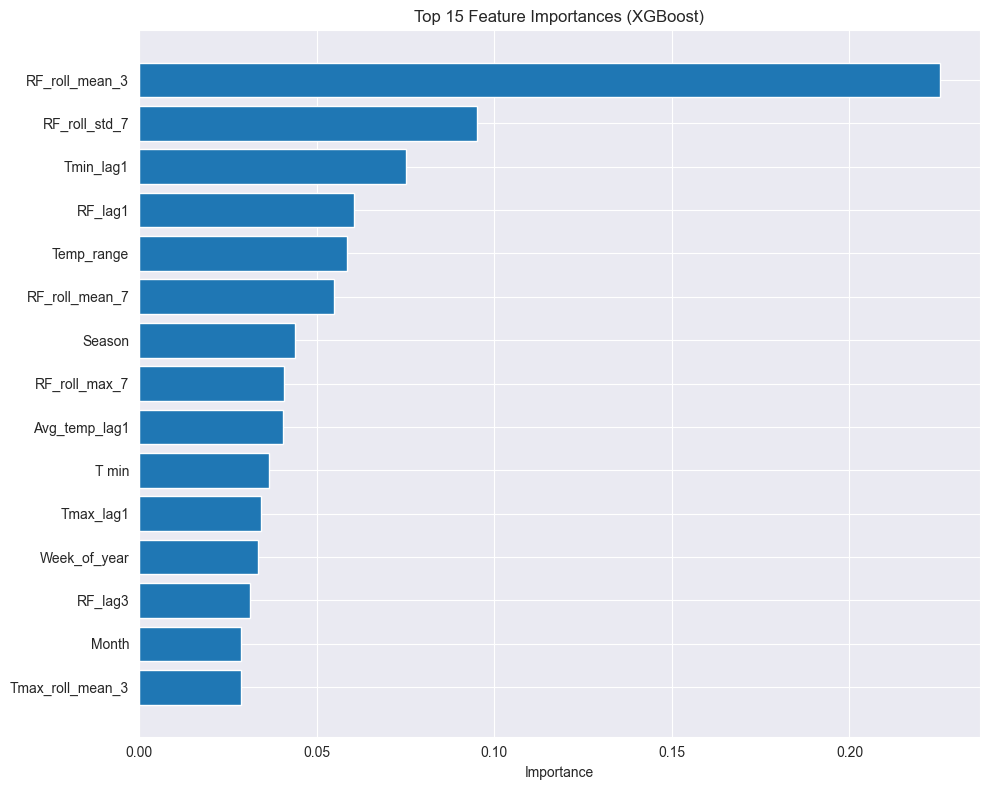

In [26]:
# Cell 12: Feature Importance Analysis (XGBoost)
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 15 Most Important Features:")
print(feature_importance.head(15))

# Plot feature importance
plt.figure(figsize=(10, 8))
plt.barh(feature_importance.head(15)['Feature'], feature_importance.head(15)['Importance'])
plt.xlabel('Importance')
plt.title('Top 15 Feature Importances (XGBoost)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


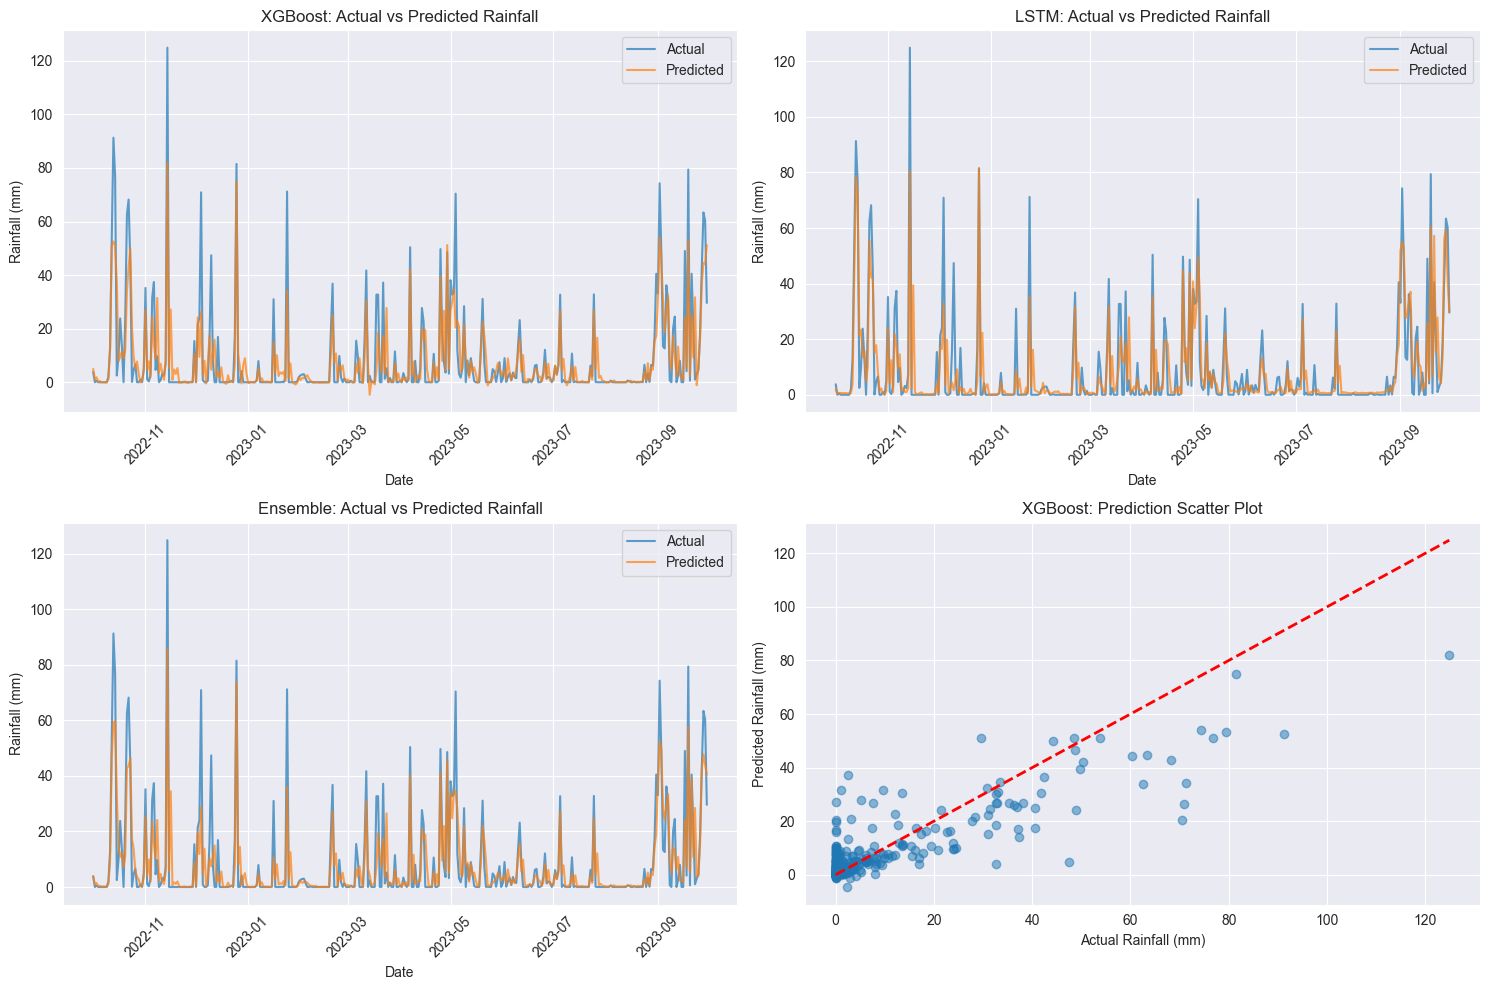

In [27]:
# Cell 13: Visualize Predictions on Test Set
# Plot actual vs predicted for test set
plt.figure(figsize=(15, 10))

# XGBoost predictions
plt.subplot(2, 2, 1)
plt.plot(y_test.index, y_test.values, label='Actual', alpha=0.7)
plt.plot(y_test.index, y_test_pred_xgb, label='Predicted', alpha=0.7)
plt.title('XGBoost: Actual vs Predicted Rainfall')
plt.xlabel('Date')
plt.ylabel('Rainfall (mm)')
plt.legend()
plt.xticks(rotation=45)

# LSTM predictions
plt.subplot(2, 2, 2)
plt.plot(y_test.index, y_test.values, label='Actual', alpha=0.7)
plt.plot(y_test.index, y_test_pred_lstm, label='Predicted', alpha=0.7)
plt.title('LSTM: Actual vs Predicted Rainfall')
plt.xlabel('Date')
plt.ylabel('Rainfall (mm)')
plt.legend()
plt.xticks(rotation=45)

# Ensemble predictions
plt.subplot(2, 2, 3)
plt.plot(y_test.index, y_test.values, label='Actual', alpha=0.7)
plt.plot(y_test.index, y_test_pred_ensemble, label='Predicted', alpha=0.7)
plt.title('Ensemble: Actual vs Predicted Rainfall')
plt.xlabel('Date')
plt.ylabel('Rainfall (mm)')
plt.legend()
plt.xticks(rotation=45)

# Scatter plot for best model
plt.subplot(2, 2, 4)
plt.scatter(y_test, y_test_pred_xgb, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Rainfall (mm)')
plt.ylabel('Predicted Rainfall (mm)')
plt.title('XGBoost: Prediction Scatter Plot')

plt.tight_layout()
plt.show()
